In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [80]:
!unzip '/content/drive/MyDrive/Group B.zip'

Archive:  /content/drive/MyDrive/Group B.zip
replace Group B/Ain_End/AHCR_00001_Ain_End_54.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: Group B/Ain_End/AHCR_00001_Ain_End_54.jpg  
  inflating: Group B/Ain_End/AHCR_00001_Ain_End_55.jpg  
  inflating: Group B/Ain_End/AHCR_00001_Ain_End_62.jpg  
  inflating: Group B/Ain_End/AHCR_00001_Ain_End_63.jpg  
  inflating: Group B/Ain_End/AHCR_00002_Ain_End_54.jpg  
  inflating: Group B/Ain_End/AHCR_00002_Ain_End_55.jpg  
  inflating: Group B/Ain_End/AHCR_00002_Ain_End_62.jpg  
  inflating: Group B/Ain_End/AHCR_00002_Ain_End_63.jpg  
  inflating: Group B/Ain_End/AHCR_00003_Ain_End_54.jpg  
  inflating: Group B/Ain_End/AHCR_00003_Ain_End_55.jpg  
  inflating: Group B/Ain_End/AHCR_00003_Ain_End_62.jpg  
  inflating: Group B/Ain_End/AHCR_00003_Ain_End_63.jpg  
  inflating: Group B/Ain_End/AHCR_00004_Ain_End_54.jpg  
  inflating: Group B/Ain_End/AHCR_00004_Ain_End_55.jpg  
  inflating: Group B/Ain_End/AHCR_00004_Ain_End_62.jpg  
  inflati

In [81]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

img_width, img_height = 150, 150
data_dir = "/content/Group B"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))  

    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):  
            for img_file in os.listdir(group_path): 
                img_path = os.path.join(group_path, img_file)
                try:
                    
                    img = tf.keras.preprocessing.image.load_img(
                        img_path, target_size=(img_width, img_height), color_mode='grayscale'
                    )
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_file} in {group_name}: {e}")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images) == 0:
    raise ValueError("No images were loaded. Check the data directory and file paths.")

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(f"Training samples: {x_train.shape[0]}, Testing samples: {x_test.shape[0]}")
print(f"Number of classes: {num_classes}")


Training samples: 2953, Testing samples: 739
Number of classes: 7


In [84]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [85]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


185/185 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.2905 - loss: 1.8226 - val_accuracy: 0.5453 - val_loss: 1.2347
Epoch 2/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.4774 - loss: 1.3420 - val_accuracy: 0.6252 - val_loss: 0.9785
Epoch 3/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.5748 - loss: 1.1445 - val_accuracy: 0.7591 - val_loss: 0.7178
Epoch 4/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.6456 - loss: 0.9478 - val_accuracy: 0.7984 - val_loss: 0.5876
Epoch 5/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.7240 - loss: 0.7880 - val_accuracy: 0.8146 - val_loss: 0.4898
Epoch 6/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.7536 - loss: 0.7214 - val_accuracy: 0.8552 - val_loss: 0.4175
Epoch 7/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.7573 - loss: 0.6902 - val_accuracy: 0.8890 - val_loss: 0.3504
Epoch 8/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.7994 - loss: 0.6005 - val_accuracy: 0.

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9296 - loss: 0.1974
Train Accuracy: 89.23%
Test Accuracy: 93.37%


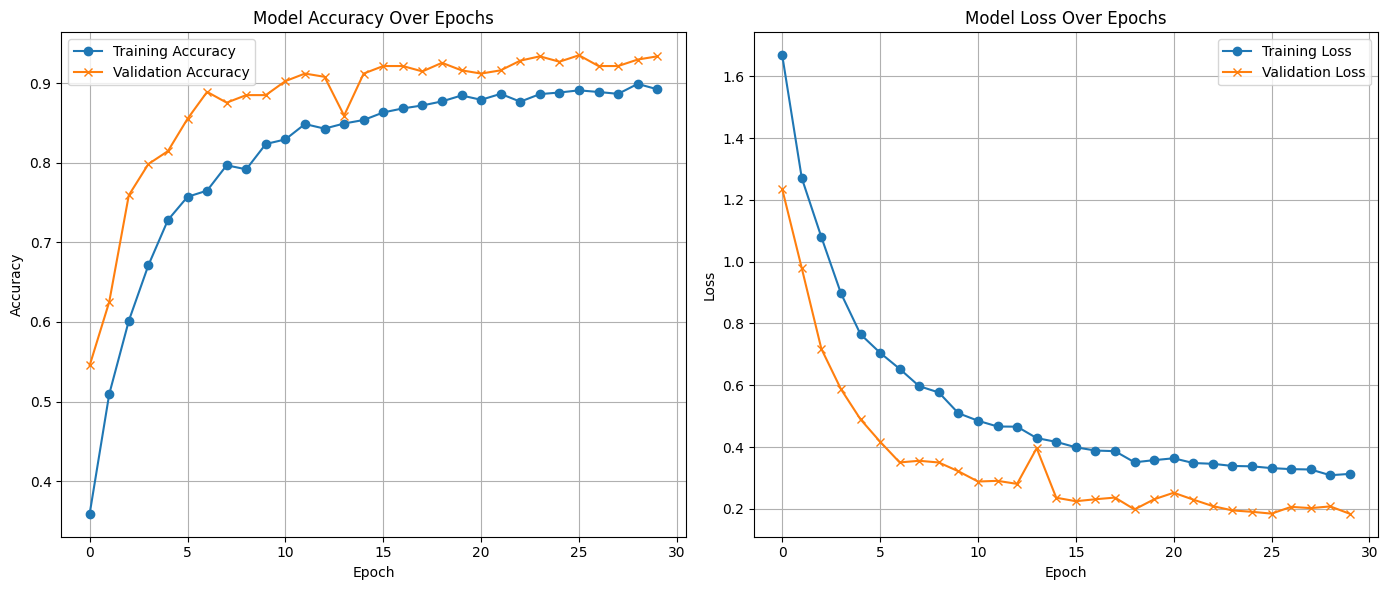

In [88]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


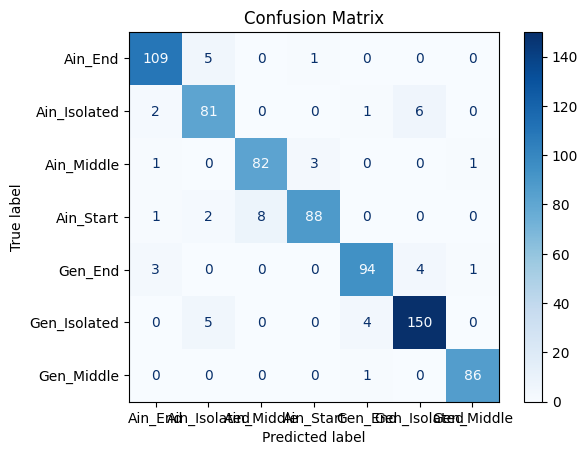

In [89]:

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


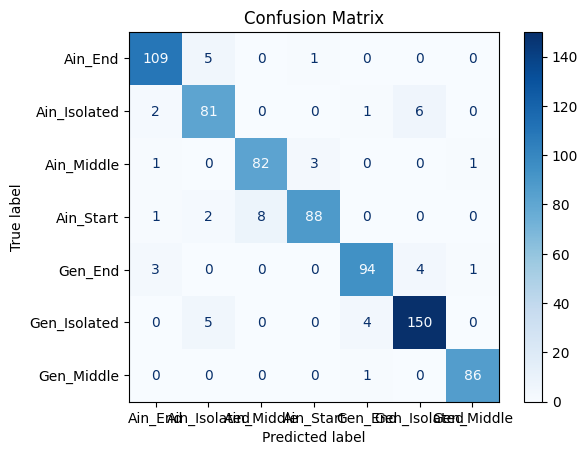

Number of incorrect predictions: 49


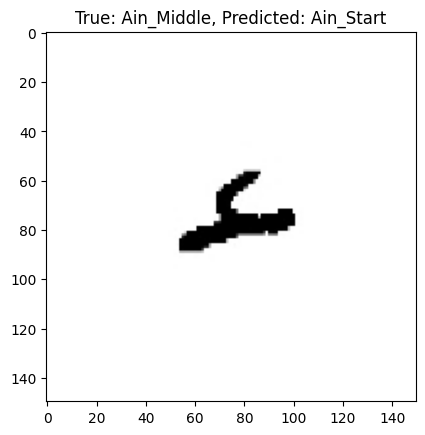

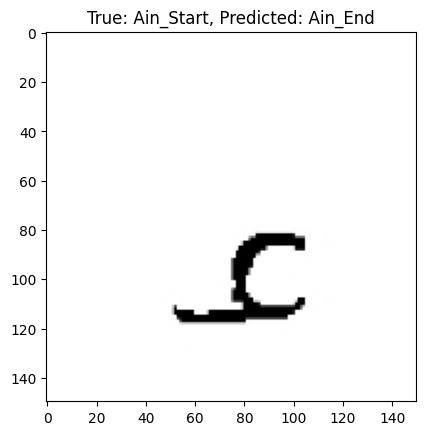

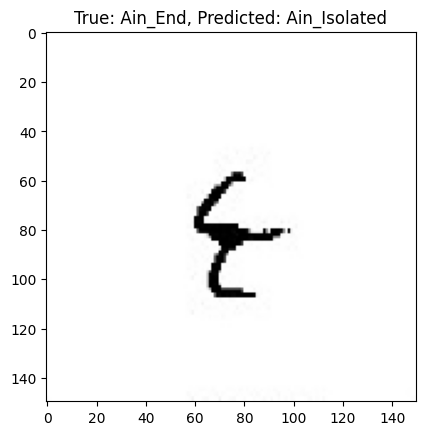

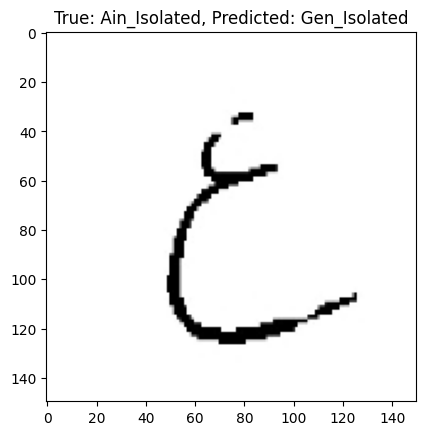

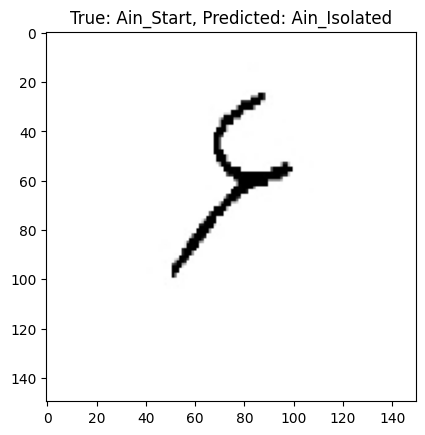

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### decrease dropout and  epochs to 28 

In [91]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [92]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [93]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=28,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/28


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.3314 - loss: 1.7480 - val_accuracy: 0.5819 - val_loss: 1.0676
Epoch 2/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.5789 - loss: 1.1079 - val_accuracy: 0.7009 - val_loss: 0.8246
Epoch 3/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.6850 - loss: 0.8239 - val_accuracy: 0.8065 - val_loss: 0.6062
Epoch 4/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7577 - loss: 0.6756 - val_accuracy: 0.8403 - val_loss: 0.4727
Epoch 5/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.7923 - loss: 0.5957 - val_accuracy: 0.8579 - val_loss: 0.4026
Epoch 6/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.8488 - loss: 0.4742 - val_accuracy: 0.8701 - val_loss: 0.3543
Epoch 7/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.8396 - loss: 0.4574 - val_accuracy: 0.8904 - val_loss: 0.3431
Epoch 8/28
185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8565 - loss: 0.4165 - val_accuracy: 

In [94]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9289 - loss: 0.2116
Train Accuracy: 93.09%
Test Accuracy: 92.69%


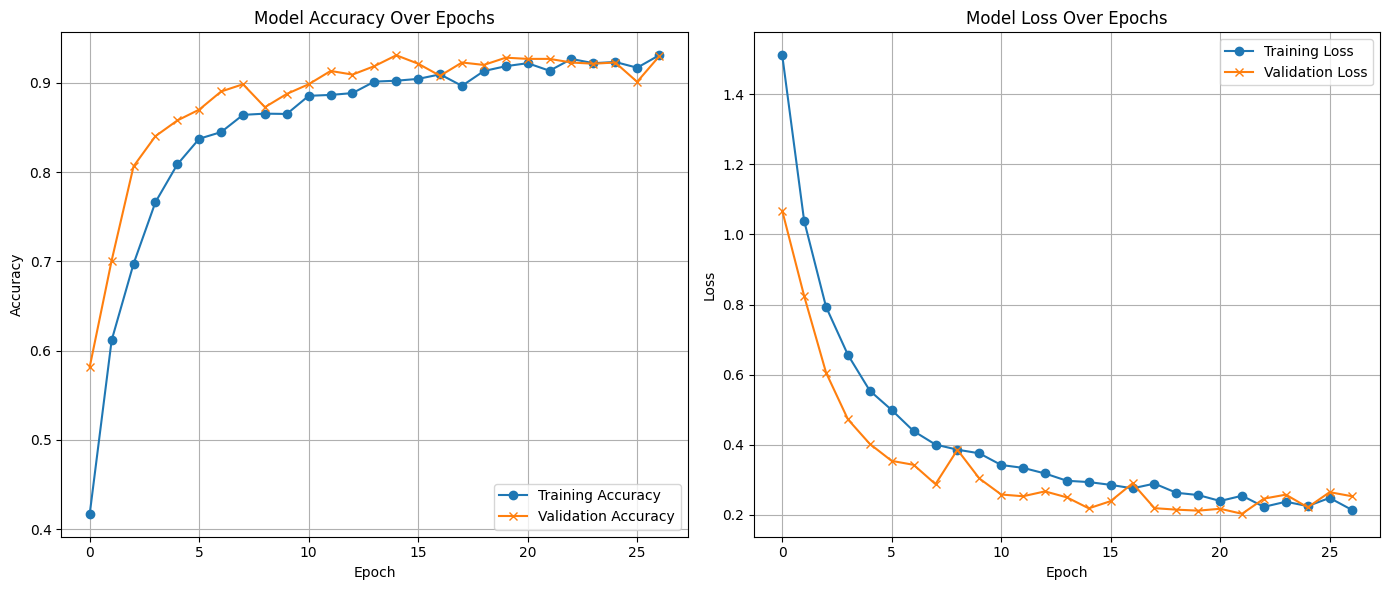

In [95]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


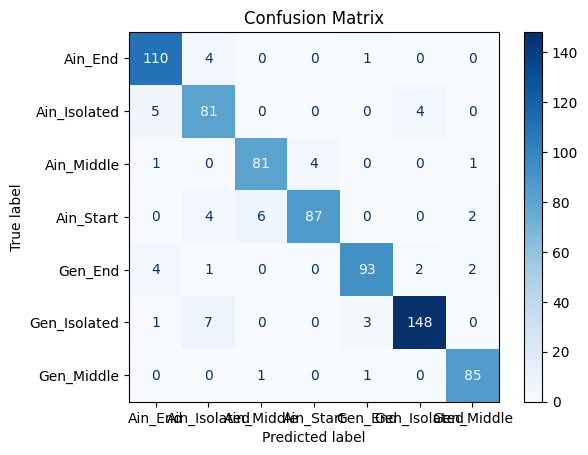

Number of incorrect predictions: 54


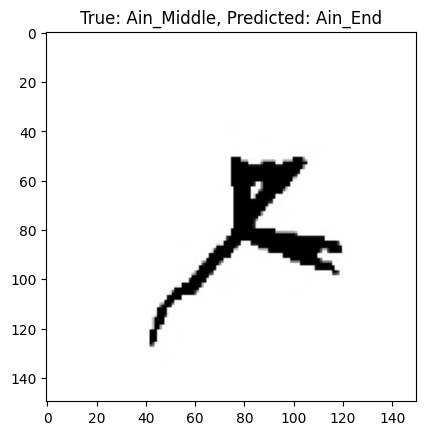

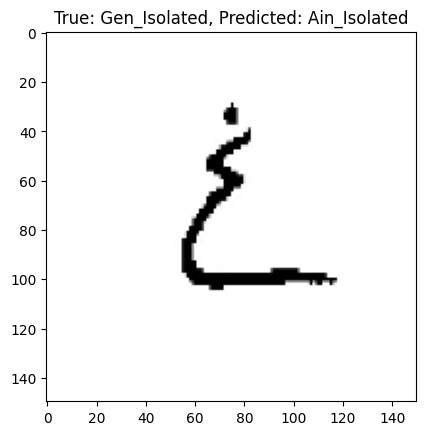

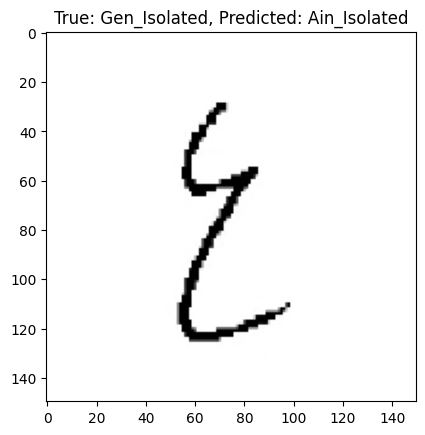

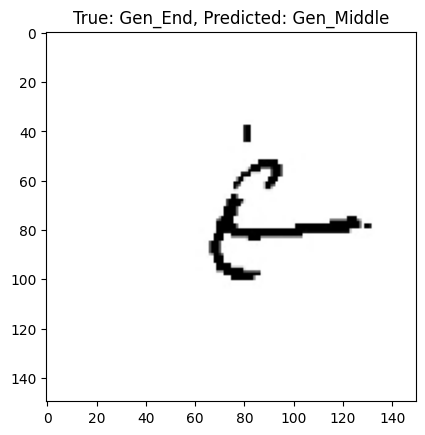

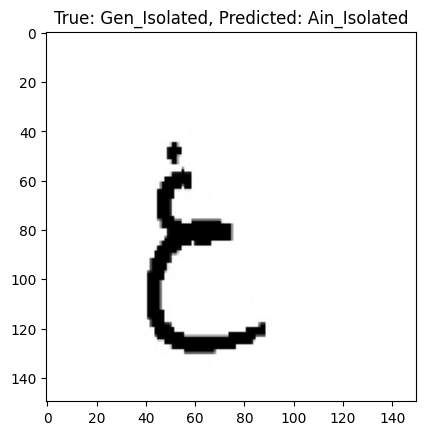

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [98]:
model.save("GrpB.keras")